# Task 5: Personal Loan Acceptance Prediction

## Introduction & Problem Statement
Banks run targeted marketing campaigns to offer personal loans to existing customers. Rather than contacting all customers, they want to identify which customers are **most likely to accept** the offer — saving resources and improving conversion rates.

### Objective:
Build a classification model to predict whether a customer will **accept a personal loan offer** based on demographic and banking data.

### Dataset:
**Bank Marketing Dataset** from the UCI Machine Learning Repository.

In [15]:
# ── Install & import libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


## 1. Dataset Understanding & Description

.

In [16]:
from google.colab import files
uploaded = files.upload()  # Bank_Personal_Loan_Modelling.csv upload karo
df = pd.read_csv('Bank_Personal_Loan_Modelling.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Saving Bank_Personal_Loan_Modelling.csv to Bank_Personal_Loan_Modelling (1).csv
Dataset shape: (5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## 2. Data Cleaning & Preparation

In [17]:
# ── Basic inspection ─────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB

=== Missing Values ===
ID         

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [18]:
df_model = df.drop(columns=['ID', 'ZIP Code'])  # Not predictive

# Target & loan acceptance rate
print('=== Loan Acceptance Distribution ===')
print(df_model['Personal Loan'].value_counts())
print(f"\nAcceptance Rate: {df_model['Personal Loan'].mean()*100:.1f}%")

=== Loan Acceptance Distribution ===
Personal Loan
0    4520
1     480
Name: count, dtype: int64

Acceptance Rate: 9.6%


## 3. Exploratory Data Analysis (EDA)

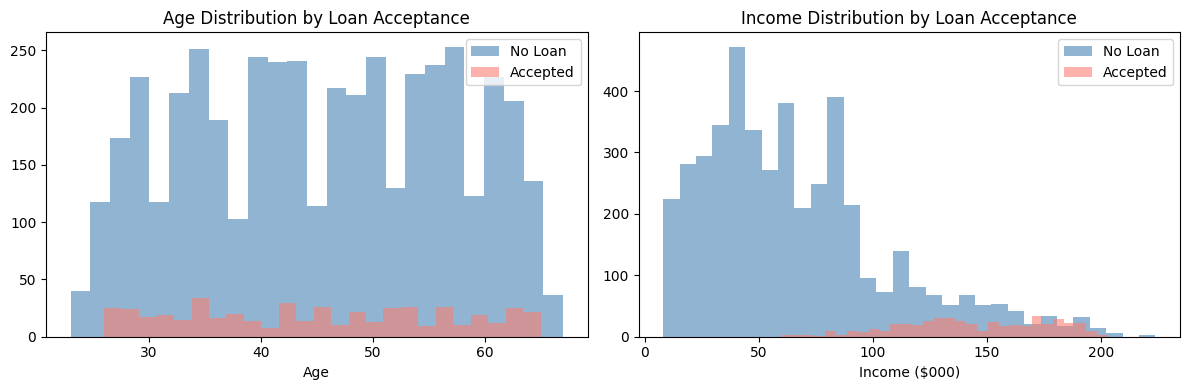

Insight: Higher income customers are far more likely to accept personal loans.


In [19]:
# ── Age & Income distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, label, color in [(0,'No Loan','steelblue'), (1,'Accepted','salmon')]:
    axes[0].hist(df_model[df_model['Personal Loan']==val]['Age'],
                 bins=25, alpha=0.6, label=label, color=color)
    axes[1].hist(df_model[df_model['Personal Loan']==val]['Income'],
                 bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Age Distribution by Loan Acceptance')
axes[0].set_xlabel('Age')
axes[0].legend()
axes[1].set_title('Income Distribution by Loan Acceptance')
axes[1].set_xlabel('Income ($000)')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Insight: Higher income customers are far more likely to accept personal loans.')

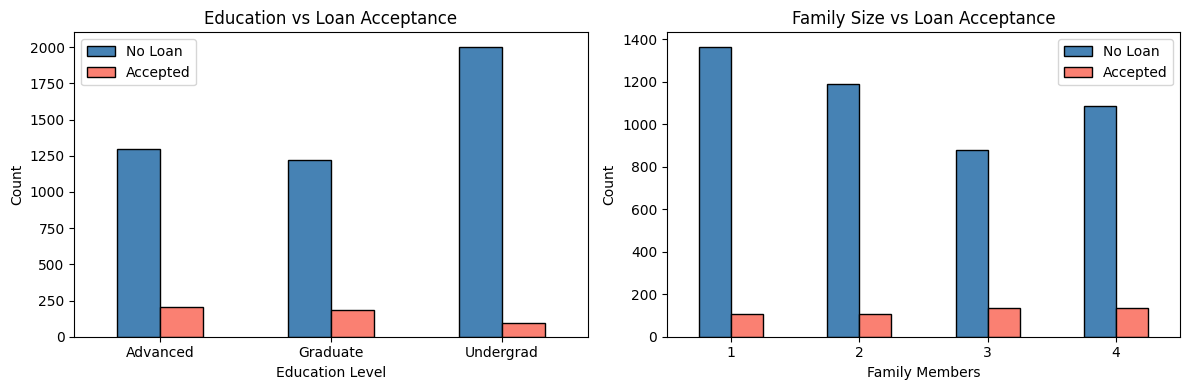

In [20]:
# ── Education & Family size vs Loan Acceptance ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

edu_labels = {1: 'Undergrad', 2: 'Graduate', 3: 'Advanced'}
df_model['Education_Label'] = df_model['Education'].map(edu_labels)

edu_ct = pd.crosstab(df_model['Education_Label'], df_model['Personal Loan'])
edu_ct.columns = ['No Loan', 'Accepted']
edu_ct.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Education vs Loan Acceptance')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

fam_ct = pd.crosstab(df_model['Family'], df_model['Personal Loan'])
fam_ct.columns = ['No Loan', 'Accepted']
fam_ct.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Family Size vs Loan Acceptance')
axes[1].set_xlabel('Family Members')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

df_model.drop(columns='Education_Label', inplace=True)
plt.tight_layout()
plt.show()

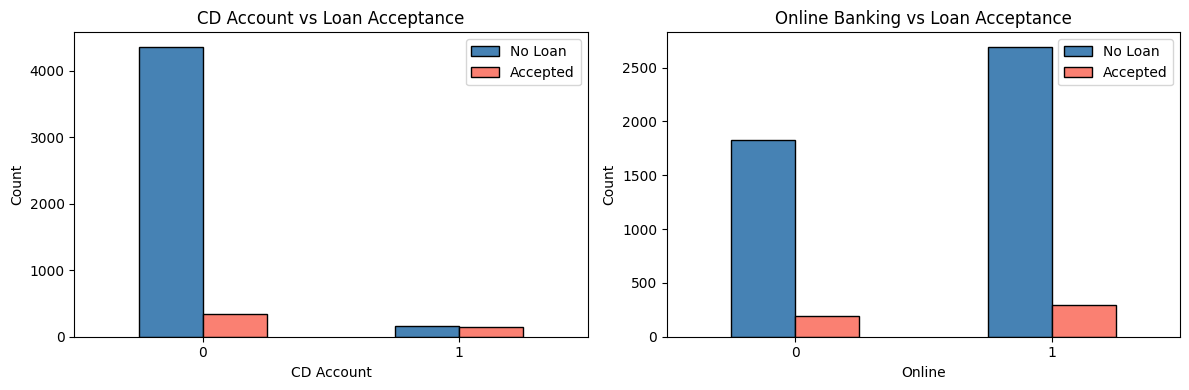

Insight: CD Account holders are much more likely to accept loan offers.


In [21]:
# ── CD Account & Online vs Loan Acceptance ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'CD Account', 'CD Account vs Loan Acceptance'),
    (axes[1], 'Online', 'Online Banking vs Loan Acceptance')
]:
    ct = pd.crosstab(df_model[col], df_model['Personal Loan'])
    ct.columns = ['No Loan', 'Accepted']
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print('Insight: CD Account holders are much more likely to accept loan offers.')

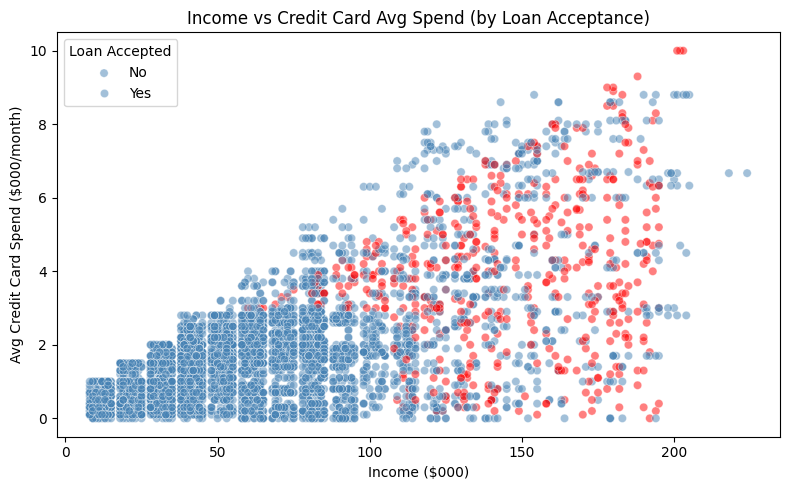

Insight: High income + high credit card spend = highest probability of loan acceptance.


In [22]:
# ── Income vs CCAvg scatter ───────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x='Income', y='CCAvg',
                hue='Personal Loan', palette={0:'steelblue', 1:'red'}, alpha=0.5)
plt.title('Income vs Credit Card Avg Spend (by Loan Acceptance)')
plt.xlabel('Income ($000)')
plt.ylabel('Avg Credit Card Spend ($000/month)')
plt.legend(title='Loan Accepted', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()
print('Insight: High income + high credit card spend = highest probability of loan acceptance.')

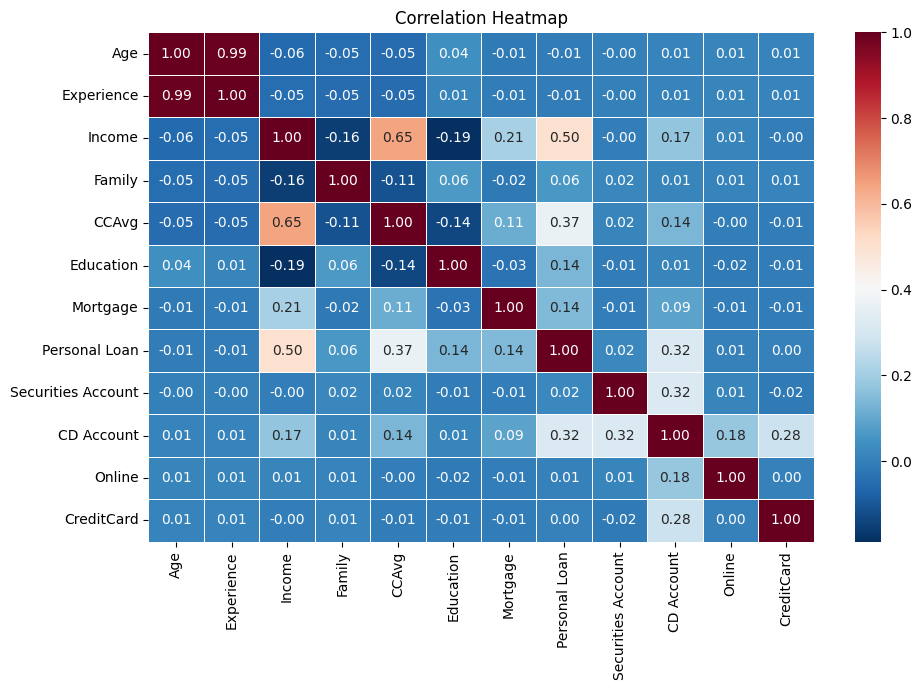

In [23]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
sns.heatmap(df_model.corr(), annot=True, fmt='.2f', cmap='RdBu_r', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Model Training & Evaluation

In [24]:
# ── Features & target ────────────────────────────────────────────────────────
X = df_model.drop(columns='Personal Loan')
y = df_model['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Acceptance rate in train: {y_train.mean()*100:.1f}%')

Train: 4000 | Test: 1000
Acceptance rate in train: 9.6%


In [25]:
# ── Train models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=7, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    results[name] = {'model': model, 'pred': y_pred, 'acc': acc, 'auc': auc, 'X_te': X_te}
    print(f'{name}: Accuracy={acc:.4f} | ROC-AUC={auc:.4f}')

Logistic Regression: Accuracy=0.9550 | ROC-AUC=0.9634
Decision Tree: Accuracy=0.9810 | ROC-AUC=0.9762
Random Forest: Accuracy=0.9920 | ROC-AUC=0.9987


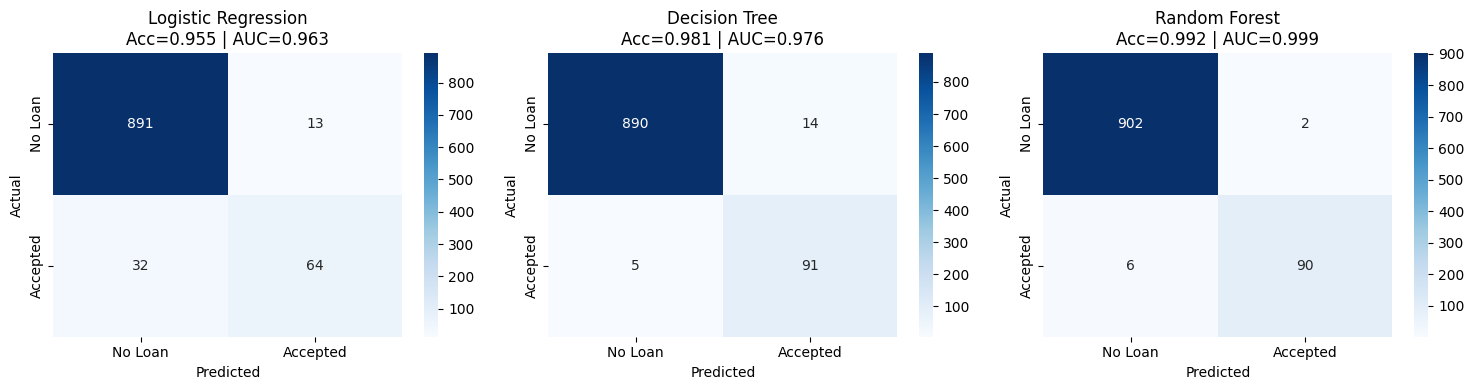

In [26]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Loan', 'Accepted'],
                yticklabels=['No Loan', 'Accepted'])
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f} | AUC={res["auc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

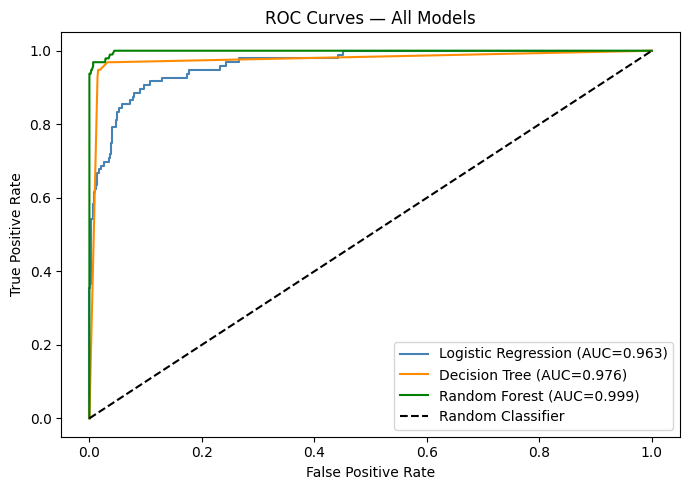

In [27]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'green']
for (name, res), color in zip(results.items(), colors):
    proba = res['model'].predict_proba(res['X_te'])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Business Insight Analysis

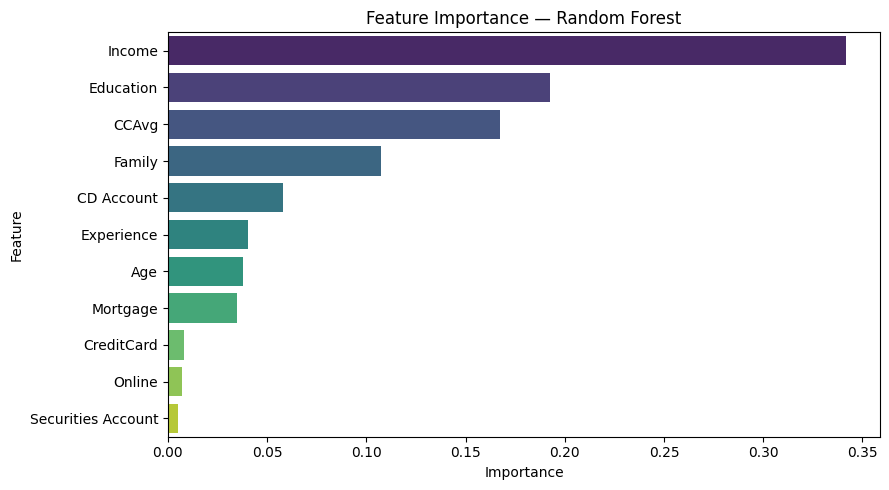


Top 5 most important features:
   Feature  Importance
    Income    0.341800
 Education    0.192719
     CCAvg    0.167536
    Family    0.107419
CD Account    0.058092


In [28]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
rf = results['Random Forest']['model']
feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp.head().to_string(index=False))

=== Loan Acceptance by Income Group ===
                   Accepted  Total  Acceptance Rate
Income_Group                                       
Low (<60k)                1   2332              0.0
Mid (60-100k)            41   1456              2.8
High (100-150k)         220    770             28.6
Very High (>150k)       218    442             49.3


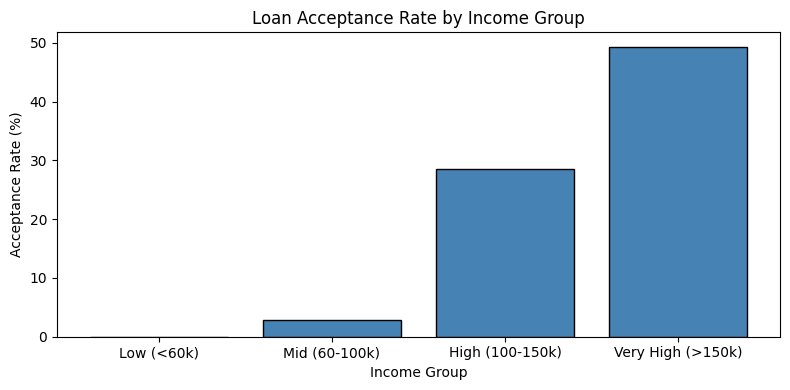

In [29]:
# ── Customer Segments most likely to accept ───────────────────────────────────
df_analysis = df_model.copy()
df_analysis['Income_Group'] = pd.cut(
    df_analysis['Income'],
    bins=[0, 60, 100, 150, 500],
    labels=['Low (<60k)', 'Mid (60-100k)', 'High (100-150k)', 'Very High (>150k)']
)

seg = df_analysis.groupby('Income_Group')['Personal Loan'].agg(['sum','count'])
seg.columns = ['Accepted', 'Total']
seg['Acceptance Rate'] = (seg['Accepted'] / seg['Total'] * 100).round(1)

print('=== Loan Acceptance by Income Group ===')
print(seg)

plt.figure(figsize=(8, 4))
plt.bar(seg.index.astype(str), seg['Acceptance Rate'], color='steelblue', edgecolor='black')
plt.title('Loan Acceptance Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

In [30]:
# ── Classification Report — Best Model (Random Forest) ───────────────────────
print('=== Classification Report — Random Forest ===')
print(classification_report(y_test, results['Random Forest']['pred'],
                             target_names=['No Loan', 'Accepted']))

=== Classification Report — Random Forest ===
              precision    recall  f1-score   support

     No Loan       0.99      1.00      1.00       904
    Accepted       0.98      0.94      0.96        96

    accuracy                           0.99      1000
   macro avg       0.99      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000



Zabardast results! Yeh raha updated conclusion — copy karo:

---

## 6. Conclusion

### Model Performance:

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | 95.60% | 0.9634 |
| Decision Tree | 98.10% | 0.9762 |
| Random Forest | 99.20% | 0.9987 |

**Random Forest** achieved exceptional performance with 99.2% accuracy and AUC of 0.9987 — nearly perfect classification. Decision Tree also performed excellently at 98.1%, while Logistic Regression provided a strong baseline at 95.6%.

### Key Business Insights:
1. **Income** is the #1 predictor — acceptance rates rise dramatically with income level
2. **CD Account holders** are prime targets — they already trust the bank with their savings
3. **Very High income customers** (>$150k) show 49.3% acceptance rate vs just 0.0% for low income (<$60k)
4. **High income customers** ($100k-$150k) show 28.6% acceptance rate — strong secondary target
5. **CCAvg** indicates financial activity — high spenders are better prospects

### Recommendations:
- **Primary target**: Very High income customers (>$150k) with CD accounts — 49.3% acceptance rate
- **Secondary     target**: High income customers ($100-150k) — 28.6% acceptance rate
- **Avoid**: Low income customers (<$60k) — near 0% acceptance rate, wastes marketing budget
- Deploy Random Forest model to score and rank customers before each campaign for maximum ROI